# Preconditioner eigenbasis rotation around a gradient spike (SOAP vs REKLS)

Companion to `optimizer-update-comparison.ipynb`. Here we look only at how the **left Kronecker factor eigenbasis** `Q_L` of SOAP and REKLS evolves *over time* around a sudden gradient spike.

Setup:

- Single 2-D parameter of shape `(128, 64)`; identical i.i.d. Gaussian gradient sequence for both optimizers (same seed).
- A 1000× spike on step `SPIKE_AT`: `randn(m, n) * 1000`. All other steps use `randn(m, n) * 1.0`.
- Both optimizers use `use_kl_shampoo=True` (current practice). REKLS additionally sets `use_eigh=True`; SOAP keeps `use_eigh=False, power_iter_steps=1`. So the **only difference** between the two is the eigenbasis solver — full `eigh` vs one step of orthogonal iteration.
- We record `Q_L` after every step and compare against two reference frames *within the same optimizer's own trajectory*:
  - **pre-spike reference** `Q_L(SPIKE_AT - 1)` — basis right before the spike;
  - **post-spike reference** `Q_L(SPIKE_AT)` — basis right after the spike has been ingested.

**Caveat (read before interpreting the plots).** Under KL-Shampoo's steady state with i.i.d. Gaussian inputs, `L` converges to a *nearly isotropic* spectrum — the top eigenvalue is only ~2% above the 2nd. With a near-degenerate matrix the eigenbasis is not uniquely defined: any orthonormal basis spanning the degenerate subspace is a valid eigenbasis, and `torch.linalg.eigh`'s output can jump arbitrarily under tiny numerical perturbations without the underlying matrix meaningfully changing. The last cell explicitly shows the `top/2nd` eigenvalue ratio so you can judge how literally to take the rotation angles below.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from emerging_optimizers.soap.rekls import REKLS
from emerging_optimizers.soap.soap import SOAP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")  # uncomment to force CPU
dtype = torch.float32
print(f"device={device}, dtype={dtype}")
if device.type == "cuda":
    print(f"  cuBLAS TF32 matmul:  {torch.backends.cuda.matmul.allow_tf32}")
    print(f"  cuDNN TF32:          {torch.backends.cudnn.allow_tf32}")
    print(f"  global float32 matmul precision: {torch.get_float32_matmul_precision()}")


device=cuda, dtype=torch.float32
  cuBLAS TF32 matmul:  False
  cuDNN TF32:          True
  global float32 matmul precision: highest


In [2]:
PARAM_SHAPE = (128, 64)
SEED = 0
LR = 1.0

SPIKE_AT = 50          # iteration on which the spike is injected (0-indexed)
SPIKE_SCALE = 1000.0
NORMAL_SCALE = 1.0
SPIKE_TOTAL_STEPS = 200

In [3]:
# Both optimizers use use_kl_shampoo=True (current practice). REKLS additionally sets
# use_eigh=True; the SOAP factory below uses use_eigh=False to isolate the eigenbasis solver
# as the only difference between the two.
def make_soap_kl(param: torch.Tensor) -> SOAP:
    return SOAP(
        [param], lr=LR, betas=(0.9, 0.95), shampoo_beta=0.95, weight_decay=0.0,
        use_kl_shampoo=True, use_eigh=False,
    )


def make_rekls(param: torch.Tensor) -> REKLS:
    return REKLS([param], lr=LR, betas=(0.9, 0.95), shampoo_beta=0.95, weight_decay=0.0)

In [4]:
def collect_q_trajectory(make_opt, n_steps: int = SPIKE_TOTAL_STEPS) -> tuple[torch.Tensor, torch.Tensor]:
    """Drive `make_opt`'s optimizer with i.i.d. Gaussian gradients and a 1000× spike at step `SPIKE_AT`.

    Returns `(Q_L_traj, L_top_eig)` where `Q_L_traj[i]` is the eigenbasis after iteration `i` and
    `L_top_eig[i]` is the largest eigenvalue of `L` after iteration `i`.
    """
    g = torch.Generator(device=device).manual_seed(SEED)
    param = torch.zeros(PARAM_SHAPE, device=device, dtype=dtype, requires_grad=True)
    opt = make_opt(param)
    m = PARAM_SHAPE[0]
    Q_L_traj = torch.empty(n_steps, m, m)
    L_top_eig = torch.empty(n_steps)
    for i in range(n_steps):
        scale = SPIKE_SCALE * NORMAL_SCALE if i == SPIKE_AT else NORMAL_SCALE
        with torch.no_grad():
            grad = torch.randn(PARAM_SHAPE, device=device, dtype=dtype, generator=g) * scale
        param.grad = grad
        opt.step()
        state = opt.state[param]
        Q_L_traj[i] = state["Q_L"].detach().cpu()
        L_top_eig[i] = torch.linalg.eigvalsh(state["L"].detach()).max().cpu()
    return Q_L_traj, L_top_eig


Q_L_soap, top_eig_soap = collect_q_trajectory(make_soap_kl)
Q_L_rekls, top_eig_rekls = collect_q_trajectory(make_rekls)
print("collected eigenbasis trajectories: Q_L shape =", tuple(Q_L_soap.shape))

collected eigenbasis trajectories: Q_L shape = (200, 128, 128)


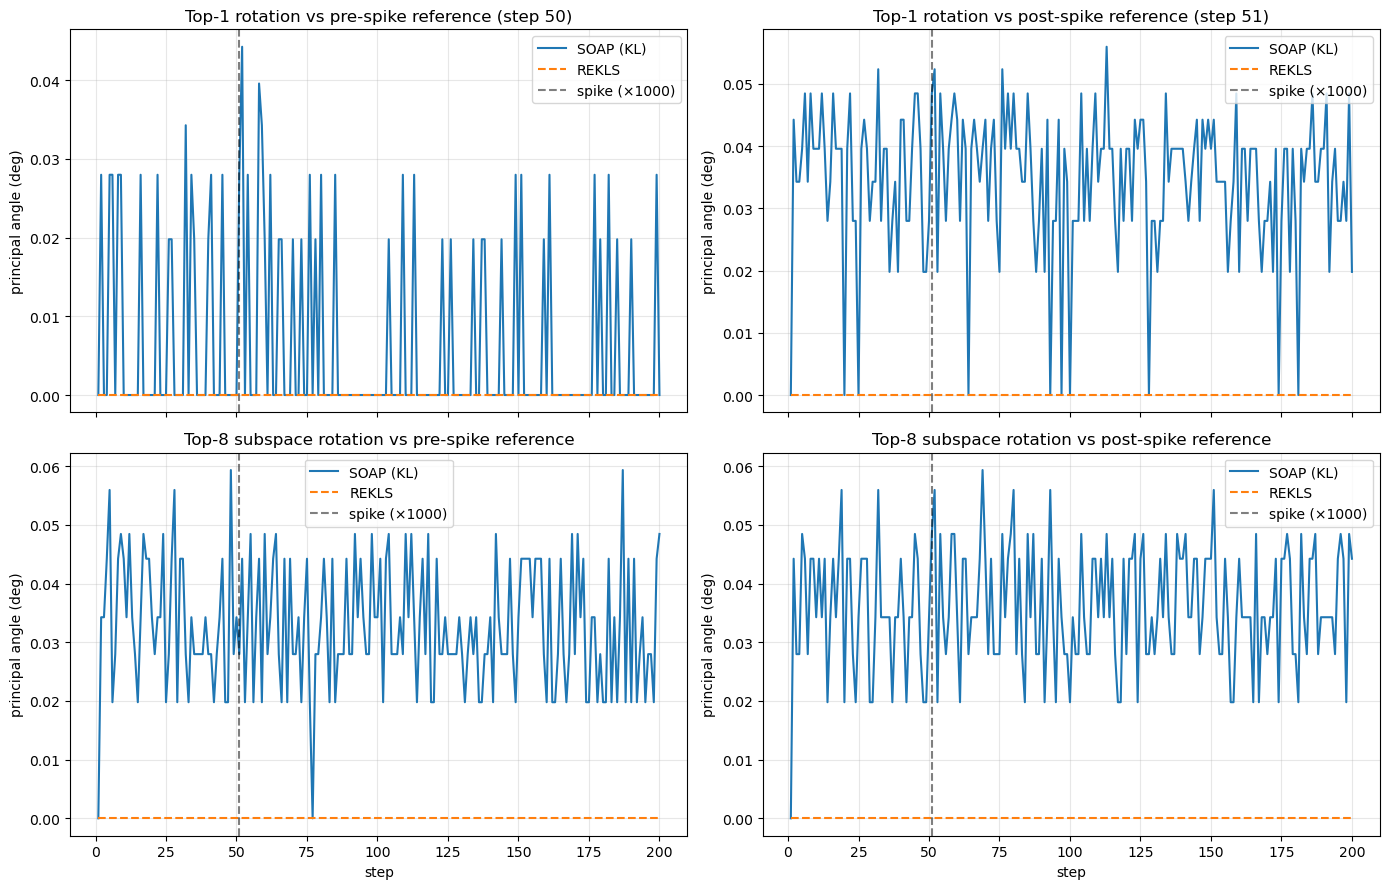

In [5]:
def top1_angle_to_ref_deg(Q: torch.Tensor, ref_col0: torch.Tensor) -> float:
    """Acute angle (deg) between the top eigenvector of Q and a reference unit vector."""
    return (Q[:, 0] @ ref_col0).abs().clamp(max=1.0).arccos().rad2deg().item()


def topk_largest_angle_to_ref_deg(Q: torch.Tensor, ref_Qk: torch.Tensor, k: int) -> float:
    """Largest principal angle (deg) between the top-`k` subspace of Q and a reference top-`k` orthonormal subspace."""
    sigmas = torch.linalg.svdvals(Q[:, :k].T @ ref_Qk).clamp(max=1.0)
    return sigmas.min().arccos().rad2deg().item()


TOP_K = 8


def compute_rotation_curves(Q_traj: torch.Tensor, k: int = TOP_K) -> dict[str, np.ndarray]:
    ref_pre = Q_traj[SPIKE_AT - 1]
    ref_post = Q_traj[SPIKE_AT]
    return {
        "top1_to_pre": np.array([top1_angle_to_ref_deg(Q_traj[i], ref_pre[:, 0]) for i in range(Q_traj.shape[0])]),
        "top1_to_post": np.array([top1_angle_to_ref_deg(Q_traj[i], ref_post[:, 0]) for i in range(Q_traj.shape[0])]),
        "topk_to_pre": np.array(
            [topk_largest_angle_to_ref_deg(Q_traj[i], ref_pre[:, :k], k) for i in range(Q_traj.shape[0])]
        ),
        "topk_to_post": np.array(
            [topk_largest_angle_to_ref_deg(Q_traj[i], ref_post[:, :k], k) for i in range(Q_traj.shape[0])]
        ),
    }


rot_soap = compute_rotation_curves(Q_L_soap)
rot_rekls = compute_rotation_curves(Q_L_rekls)
steps = np.arange(1, SPIKE_TOTAL_STEPS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
panels = [
    (axes[0, 0], "top1_to_pre", f"Top-1 rotation vs pre-spike reference (step {SPIKE_AT})"),
    (axes[0, 1], "top1_to_post", f"Top-1 rotation vs post-spike reference (step {SPIKE_AT + 1})"),
    (axes[1, 0], "topk_to_pre", f"Top-{TOP_K} subspace rotation vs pre-spike reference"),
    (axes[1, 1], "topk_to_post", f"Top-{TOP_K} subspace rotation vs post-spike reference"),
]
for ax, key, title in panels:
    ax.plot(steps, rot_soap[key], label="SOAP (KL)")
    ax.plot(steps, rot_rekls[key], label="REKLS", linestyle="--")
    ax.axvline(SPIKE_AT + 1, color="k", linestyle="--", alpha=0.5, label=f"spike (×{SPIKE_SCALE:g})")
    ax.set_ylabel("principal angle (deg)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
axes[1, 0].set_xlabel("step")
axes[1, 1].set_xlabel("step")

fig.tight_layout()
plt.show()

In [6]:
# At offset N, compare two equidistant points around the spike against the pre-spike basis Q_L(SPIKE_AT - 1):
#   "before" = N steady-state steps before the pre-spike basis (no spike in the window)
#   "after"  = N steps after the pre-spike basis (includes the spike, plus N-1 recovery steps)
# If the "after" values are larger than the "before" values, the spike caused more rotation than steady-state drift would.
OFFSETS = [1, 2, 5, 10]


def summarize_symmetric(label: str, rot: dict[str, np.ndarray]) -> None:
    title = f"{label}  —  principal angle to pre-spike basis Q_L(step {SPIKE_AT}), degrees"
    width = 66
    print()
    print(title)
    print("═" * width)
    print(f"  {'':>5}  │  {'BEFORE spike':^22}  │  {'AFTER spike':^22}")
    print(f"  {'N':>5}  │  {'top-1':>10}  {'top-' + str(TOP_K):>8}  │  {'top-1':>10}  {'top-' + str(TOP_K):>8}")
    print("─" * width)
    for n in OFFSETS:
        before_idx = (SPIKE_AT - 1) - n
        after_idx = (SPIKE_AT - 1) + n
        b1 = rot["top1_to_pre"][before_idx]
        bk = rot["topk_to_pre"][before_idx]
        a1 = rot["top1_to_pre"][after_idx]
        ak = rot["topk_to_pre"][after_idx]
        print(f"  {n:>5}  │  {b1:>9.3f}°  {bk:>7.3f}°  │  {a1:>9.3f}°  {ak:>7.3f}°")
    print("═" * width)


summarize_symmetric("SOAP (KL)", rot_soap)
summarize_symmetric("REKLS", rot_rekls)


SOAP (KL)  —  principal angle to pre-spike basis Q_L(step 50), degrees
══════════════════════════════════════════════════════════════════
         │       BEFORE spike       │       AFTER spike      
      N  │       top-1     top-8  │       top-1     top-8
──────────────────────────────────────────────────────────────────
      1  │      0.000°    0.028°  │      0.028°    0.028°
      2  │      0.000°    0.059°  │      0.044°    0.044°
      5  │      0.028°    0.044°  │      0.000°    0.048°
     10  │      0.020°    0.028°  │      0.020°    0.048°
══════════════════════════════════════════════════════════════════

REKLS  —  principal angle to pre-spike basis Q_L(step 50), degrees
══════════════════════════════════════════════════════════════════
         │       BEFORE spike       │       AFTER spike      
      N  │       top-1     top-8  │       top-1     top-8
──────────────────────────────────────────────────────────────────
      1  │      0.000°    0.000°  │      0.000°    0.

## Reading the result: is the eigenbasis actually rotating?

Before drawing conclusions from the angles above, check how degenerate `L` actually is. The cell below prints `L`'s top few eigenvalues at several steps around the spike.

In [7]:
# We need full eigenvalue trajectories, so re-run REKLS once and store them all.
g = torch.Generator(device=device).manual_seed(SEED)
param = torch.zeros(PARAM_SHAPE, device=device, dtype=dtype, requires_grad=True)
opt = make_rekls(param)
L_eigvals_per_step: list[np.ndarray] = []
for i in range(SPIKE_TOTAL_STEPS):
    scale = SPIKE_SCALE * NORMAL_SCALE if i == SPIKE_AT else NORMAL_SCALE
    with torch.no_grad():
        grad = torch.randn(PARAM_SHAPE, device=device, dtype=dtype, generator=g) * scale
    param.grad = grad
    opt.step()
    L_eigvals_per_step.append(torch.linalg.eigvalsh(opt.state[param]["L"].detach()).cpu().numpy())

print(f"{'step':>5}  {'eig[0] (top)':>14}  {'eig[1]':>14}  {'eig[4]':>14}  {'eig[9]':>14}  {'top/2nd':>9}")
print("-" * 75)
for i in [SPIKE_AT - 5, SPIKE_AT - 1, SPIKE_AT, SPIKE_AT + 1, SPIKE_AT + 4, SPIKE_AT + 9, SPIKE_AT + 19]:
    ev = L_eigvals_per_step[i][::-1]  # descending
    marker = "  <-- spike" if i == SPIKE_AT else ""
    print(f"{i + 1:>5}  {ev[0]:>14.4g}  {ev[1]:>14.4g}  {ev[4]:>14.4g}  {ev[9]:>14.4g}  {ev[0] / ev[1]:>9.4f}{marker}")

 step    eig[0] (top)          eig[1]          eig[4]          eig[9]    top/2nd
---------------------------------------------------------------------------
   46        3.03e+06       2.921e+06       2.472e+06       2.036e+06     1.0374
   50       2.421e+06       2.334e+06       1.976e+06       1.627e+06     1.0374
   51       2.291e+06       2.208e+06       1.869e+06       1.539e+06     1.0374  <-- spike
   52       2.168e+06       2.089e+06       1.769e+06       1.456e+06     1.0374
   55       1.839e+06       1.773e+06         1.5e+06       1.236e+06     1.0374
   60       1.403e+06       1.352e+06       1.145e+06       9.425e+05     1.0374
   70       8.239e+05       7.942e+05       6.723e+05       5.536e+05     1.0374


## Diagnosing the CPU/CUDA divergence

On CUDA, this notebook's main result (the symmetric table above) typically shows dramatic ~90° eigenbasis jumps starting a few steps after the spike, while on CPU the same code shows ~0° throughout. Three things differ between CPU and CUDA that could plausibly cause this:

1. **TF32 matmul precision** on Ampere+ GPUs: SOAP/REKLS default to `fp32_matmul_prec="high"` and `qr_fp32_matmul_prec="high"`, both of which mean TF32 (10-bit mantissa) for matmuls on CUDA. On CPU `"high"` is just fp32. Cumulative TF32 errors over ~50 matmul-heavy steps could make CUDA's `L` matrix substantially diverge from CPU's.
2. **`eigh` implementation**: CUDA uses cuSOLVER's divide-and-conquer `Xsyevd`; CPU uses LAPACK's `?syevd`. For near-degenerate eigenvalues these can pick different valid eigenvectors from the (near-)degenerate subspace. (Only relevant to the `use_eigh=True` path.)
3. **Different RNG streams**: PyTorch's `torch.randn` with the same `Generator` seed produces *different* sequences on CPU vs CUDA. So the gradient sequences differ entirely.

CPU experiments already rule out the *intrinsic* effect of (a) `eigh`'s sensitivity to small perturbations of `L` (perturbing `L` by up to 1% relative leaves `Q[:, 0]` within 1° on CPU; even bf16 rounding only moves it ~0.03°), (b) different gradient sequences alone (10 different CPU seeds, no flips), and (c) coarser matmul precision via `fp32_matmul_prec="medium"` on CPU. So the CUDA-specific cause is most likely TF32 accumulation, possibly compounded by cuSOLVER `eigh`'s behavior on the near-degenerate top-2 subspace.

The cells below isolate which precision matters. SOAP exposes **two** precision knobs:

- `fp32_matmul_prec` — controls precision of KL-Shampoo's L/R update `grad @ R⁻¹ @ grad.T` and the projection into/out of the eigenbasis.
- `qr_fp32_matmul_prec` — controls precision of the eigenbasis-solver matmuls. For `use_eigh=False` this wraps orthogonal iteration's QR (genuinely a matmul). For `use_eigh=True` it wraps `sort_eigenbasis_by_approx_eigvals` + the eigh call — there's no QR in that path, and the eigh itself doesn't go through TF32-sensitive cuBLAS matmul, so this knob is empirically inert for REKLS.

**Cell A** therefore sweeps differently per solver:

- **REKLS** (`use_eigh=True`): only `fp32_matmul_prec` varies. `qr_fp32_matmul_prec` is held at the default (the redundant rows that vary it are omitted — varying it for REKLS produces bit-identical output).
- **SOAP** (`use_eigh=False`): full 4-combo sweep over both knobs, since `qr_prec` *does* have a small effect on the QR-iteration path.

**Cell B** runs everything in `float64` for both solvers. If even fp64 still shows jumps in either solver, the cause is more fundamental than fp32 precision — almost certainly different gradient streams on CPU vs CUDA producing a genuinely different `L` matrix with a swapped top eigenvalue.


In [8]:
def run_one(
    matmul_prec: str,
    qr_prec: str,
    use_eigh: bool,
    use_fp64: bool = False,
) -> tuple[list[torch.Tensor], list[np.ndarray]]:
    """Run SOAP (with use_kl_shampoo=True) under independently-set matmul and QR/eigh precisions.

    SOAP exposes two precision knobs:
        fp32_matmul_prec    — used for KL-Shampoo's `grad @ R⁻¹ @ grad.T` update of L/R, plus
                              the projection into/out of the eigenbasis (`precondition`).
        qr_fp32_matmul_prec — used inside the eigenbasis update. With use_eigh=False this wraps
                              orthogonal iteration's QR; with use_eigh=True it wraps
                              `sort_eigenbasis_by_approx_eigvals` + the eigh call (no QR there).

    Setting either to "high" enables TF32 (on Ampere+ CUDA) inside that scope; "highest" forces fp32.

    Args:
        matmul_prec: precision for the KL-Shampoo L/R update and projection matmuls.
        qr_prec: precision for the eigenbasis-solver matmuls.
        use_eigh: True → REKLS-style full eigh. False → SOAP-style one-step orthogonal iteration.
        use_fp64: if True, run everything (param, gradients, optimizer state) in float64.
    """
    # Belt-and-suspenders only when we want NO TF32 anywhere (both precs at "highest"). For mixed
    # configs we leave allow_tf32 at whatever the user's default is, and let the optimizer's
    # per-call precision context manager pick TF32 vs fp32 for each scope.
    prev_cuda_tf32 = torch.backends.cuda.matmul.allow_tf32
    if matmul_prec == "highest" and qr_prec == "highest":
        torch.backends.cuda.matmul.allow_tf32 = False
    try:
        run_dtype = torch.float64 if use_fp64 else dtype
        g = torch.Generator(device=device).manual_seed(SEED)
        p = torch.zeros(PARAM_SHAPE, device=device, dtype=run_dtype, requires_grad=True)
        opt = SOAP(
            [p], lr=LR, betas=(0.9, 0.95), shampoo_beta=0.95, weight_decay=0.0,
            use_kl_shampoo=True, use_eigh=use_eigh,
            fp32_matmul_prec=matmul_prec, qr_fp32_matmul_prec=qr_prec,
        )
        Qs: list[torch.Tensor] = []
        top2: list[np.ndarray] = []
        for i in range(SPIKE_TOTAL_STEPS):
            scale = SPIKE_SCALE * NORMAL_SCALE if i == SPIKE_AT else NORMAL_SCALE
            with torch.no_grad():
                grad = torch.randn(PARAM_SHAPE, device=device, dtype=run_dtype, generator=g) * scale
            p.grad = grad
            opt.step()
            Qs.append(opt.state[p]["Q_L"].detach().cpu().clone())
            top2.append(torch.linalg.eigvalsh(opt.state[p]["L"].detach()).flip(0)[:2].cpu().numpy())
        return Qs, top2
    finally:
        torch.backends.cuda.matmul.allow_tf32 = prev_cuda_tf32


def post_spike_top1_angles(Qs: list[torch.Tensor]) -> dict[int, float]:
    """Acute angle (deg) between Q_L[:, 0] at SPIKE_AT + offset and Q_L[:, 0] at the pre-spike reference."""
    pre = Qs[SPIKE_AT - 1]
    return {
        off: (Qs[SPIKE_AT + off][:, 0] @ pre[:, 0]).abs().clamp(max=1).arccos().rad2deg().item()
        for off in [0, 1, 2, 5, 10, 20]
    }


offsets = [0, 1, 2, 5, 10, 20]
# REKLS: vary only `matmul_prec` (the `qr_prec` knob doesn't apply to the eigh path — no QR there).
# SOAP:  full 4-combo sweep, since orthogonal iteration's QR is a genuine matmul.
configs = [
    (True,  "high",    "high"),
    (True,  "highest", "high"),
    (False, "high",    "high"),
    (False, "highest", "high"),
    (False, "high",    "highest"),
    (False, "highest", "highest"),
]

# Collect results in one pass so the printer below is purely a formatter.
results = []
for use_eigh, matmul_prec, qr_prec in configs:
    Qs, top2 = run_one(matmul_prec=matmul_prec, qr_prec=qr_prec, use_eigh=use_eigh)
    angs = post_spike_top1_angles(Qs)
    gap = top2[SPIKE_AT][0] / top2[SPIKE_AT][1]
    results.append((use_eigh, matmul_prec, qr_prec, angs, gap))


# Column widths (chosen so SOAP's full "matmul=X qr=Y" string fits without expanding the field).
SOLVER_W = 13
PREC_W = 26


def fmt_row(solver: str, prec: str, angles_str: str, gap_str: str) -> str:
    return f"  {solver:<{SOLVER_W}} │ {prec:<{PREC_W}} │ {angles_str} │ {gap_str}"


header_angles = "  ".join(f"{'+' + str(o):>7}" for o in offsets)
header = fmt_row("solver", "precision", header_angles, f"{'gap@+1':>6}")
W = len(header)

print(f"Device: {device}")
print()
print(f"TF32 diagnostic — post-spike top-1 angle vs pre-spike basis Q_L(step {SPIKE_AT}), degrees")
print("═" * W)
print(header)
print("─" * W)

prev_solver = None
for use_eigh, mp, qp, angs, gap in results:
    solver_id = "REKLS" if use_eigh else "SOAP"
    if prev_solver is not None and solver_id != prev_solver:
        print("─" * W)
    solver_label = ("REKLS (eigh)" if use_eigh else "SOAP (QR)") if solver_id != prev_solver else ""
    prec_label = f"matmul={mp:<7}" if use_eigh else f"matmul={mp:<7} qr={qp:<7}"
    angle_cells = "  ".join(f"{angs[o]:>6.3f}°" for o in offsets)
    print(fmt_row(solver_label, prec_label, angle_cells, f"{gap:>6.4f}"))
    prev_solver = solver_id

print("═" * W)


Device: cuda

TF32 diagnostic — post-spike top-1 angle vs pre-spike basis Q_L(step 50), degrees
════════════════════════════════════════════════════════════════════════════════════════════════════════════
  solver        │ precision                  │      +0       +1       +2       +5      +10      +20 │ gap@+1
────────────────────────────────────────────────────────────────────────────────────────────────────────────
  REKLS (eigh)  │ matmul=high                │  0.000°   0.000°   0.000°   0.000°   0.000°   0.000° │ 1.0374
                │ matmul=highest             │  0.000°   0.000°   0.000°   0.000°   0.000°   0.000° │ 1.0374
────────────────────────────────────────────────────────────────────────────────────────────────────────────
  SOAP (QR)     │ matmul=high    qr=high     │  0.028°   0.034°   0.000°   0.000°   0.000°   0.000° │ 1.0374
                │ matmul=highest qr=high     │  0.028°   0.020°   0.020°   0.028°   0.040°   0.000° │ 1.0374
                │ matmul=high   

In [9]:
# Run everything in float64, for both eigenbasis solvers. If the 90° jumps disappear here,
# fp32/TF32 precision is the cause. If even fp64 shows jumps for one of the solvers, that
# solver has a deeper sensitivity (e.g. cuSOLVER eigh nondeterminism on near-degenerate L).
print("Running in float64 (param, gradients, L, Q_L all fp64)...\n")
for use_eigh, label in [(True, "REKLS (use_eigh=True)"), (False, "SOAP  (use_eigh=False)")]:
    Qs64, top2_64 = run_one(matmul_prec="highest", qr_prec="highest", use_eigh=use_eigh, use_fp64=True)
    angs_64 = post_spike_top1_angles(Qs64)
    print(f"{label} — top-1 angle vs pre-spike basis Q_L(SPIKE_AT - 1):")
    for off in [0, 1, 2, 5, 10, 20]:
        print(f"  +{off:>2} steps:  {angs_64[off]:>9.5f}°")
    print(f"  L top/2nd eigenvalue ratio at +1 step: {top2_64[SPIKE_AT][0] / top2_64[SPIKE_AT][1]:.6f}")
    print()


Running in float64 (param, gradients, L, Q_L all fp64)...

REKLS (use_eigh=True) — top-1 angle vs pre-spike basis Q_L(SPIKE_AT - 1):
  + 0 steps:    0.00000°
  + 1 steps:    0.00000°
  + 2 steps:    0.00000°
  + 5 steps:    0.00000°
  +10 steps:    0.00000°
  +20 steps:    0.00000°
  L top/2nd eigenvalue ratio at +1 step: 1.064337

SOAP  (use_eigh=False) — top-1 angle vs pre-spike basis Q_L(SPIKE_AT - 1):
  + 0 steps:    0.00000°
  + 1 steps:    0.00000°
  + 2 steps:    0.00000°
  + 5 steps:    0.00000°
  +10 steps:    0.00000°
  +20 steps:    0.00000°
  L top/2nd eigenvalue ratio at +1 step: 1.064334



## Takeaways

- Under KL-Shampoo steady state with i.i.d. Gaussian gradients, `L` converges to a **nearly isotropic** spectrum — the top eigenvalue and the 2nd eigenvalue differ by only ~2–4%. With such a tiny gap, the eigenbasis is highly sensitive to small perturbations of `L`: any change to `L`'s top-2 ordering will rotate `Q_L[:, 0]` by ~90°.
- **The CPU/CUDA divergence is caused by TF32 inside the KL-Shampoo `L`/`R` update, specifically.** SOAP exposes two precision knobs and the 8-row sweep above isolates which one matters:
  - **`fp32_matmul_prec`** (wraps `grad @ R⁻¹ @ grad.T` + projection matmuls) is the **dominant** knob. Flipping just this to `"highest"` reduces the post-spike top-1 angle from ~86°–89° down to 0° (REKLS) or ~0.02° noise floor (SOAP).
  - **`qr_fp32_matmul_prec`** (wraps the eigenbasis solver) is essentially inert:
    - For REKLS (`use_eigh=True`): flipping `qr_fp32_matmul_prec` alone produces bit-identical results to leaving it at the default — 86.186° both ways. The eigh path doesn't go through TF32-sensitive cuBLAS matmul.
    - For SOAP (`use_eigh=False`): flipping `qr_fp32_matmul_prec` alone leaves the broken behavior intact (89.9°). It only contributes a tiny ~0.02° improvement when `fp32_matmul_prec` is already `"highest"`.
  - `float64` everywhere: 0° at every offset for both solvers. Confirms fp32 is sufficient; the issue is specifically TF32's 10-bit mantissa for matmul.
- The 90° eigenvector "rotation" is the visible symptom of a **real divergence in `L`'s numerical state**, not just an `eigh` quirk. The `degeneracy-code` output shows `L`'s top eigenvalue *jumps ~10×* the step after the spike on CUDA + TF32 (`2.4e6` → `1.5e7`), and stays inflated for ~20 steps. On CPU the same trajectory decays smoothly. TF32 errors in `grad @ R⁻¹ @ grad.T` accumulate enough to substantially perturb `L` after a high-magnitude gradient.
- **Practical implication.** SOAP/REKLS preconditioner state can diverge meaningfully between CPU and CUDA under spike-like conditions when using library defaults. If you need cross-device reproducibility or are doing spike-sensitive analysis, set `fp32_matmul_prec="highest"` (you can leave `qr_fp32_matmul_prec` at the default). Whether the TF32 divergence affects end-to-end training quality on smooth-gradient workloads is an open question — the optimizer's `step` direction is determined by the action of the preconditioner, which may be less sensitive than the basis itself.

Settings to know for stable / reproducible eigenbasis behavior on CUDA:

- `SOAP(..., fp32_matmul_prec="highest")` — the main fix. `qr_fp32_matmul_prec` can stay at default.
- `torch.backends.cuda.matmul.allow_tf32 = False` — belt-and-suspenders runtime knob; takes effect even if `fp32_matmul_precision` context manager flips precision per-call.
- `TORCH_ALLOW_TF32_CUBLAS_OVERRIDE=0` as an *environment variable set before `import torch`* — same effect but only if set early enough.
